In [37]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_pedestrians_covid.csv')
df['ds'] = pd.to_datetime(df['ds'])
print(df.shape)
df.head()

(1490, 2)


,ds,y
0,2017-06-02,39230
1,2017-06-03,35290
2,2017-06-04,27083
3,2017-06-05,28727
4,2017-06-06,30315


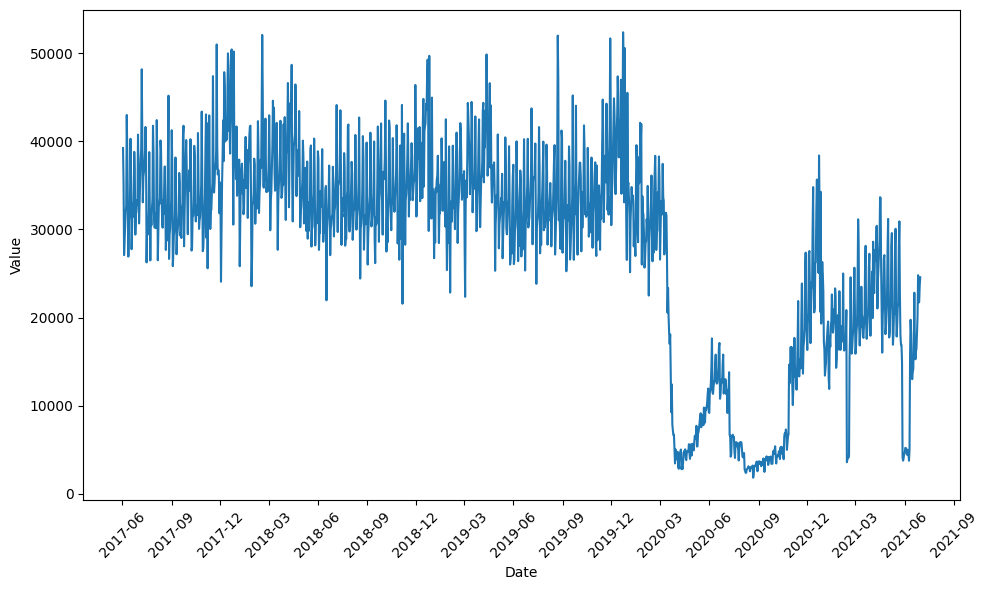

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'])

plt.xlabel('Date')
plt.ylabel('Value')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pre-Covid

(944, 2)


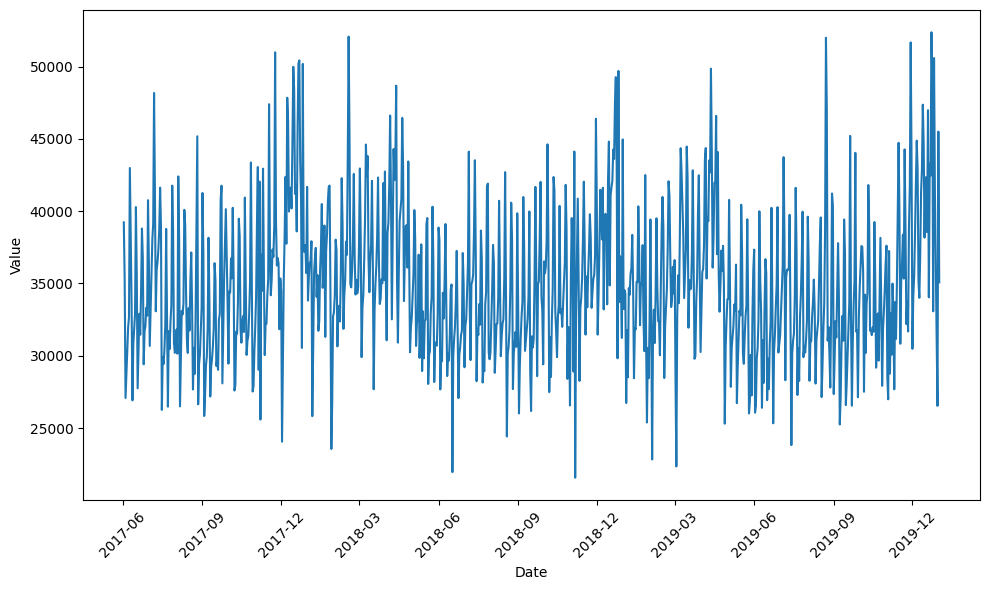

In [15]:
df_pre = df[df['ds'] <= "2020-01-01"]
print(df_pre.shape)

plt.figure(figsize=(10, 6))
plt.plot(df_pre['ds'], df_pre['y'])

plt.xlabel('Date')
plt.ylabel('Value')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
m = Prophet(growth="flat", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
X = df_pre[df_pre['ds'] <= "2019-01-01"]
test = df_pre[df_pre['ds'] > "2019-01-01"]
m.fit(X)

15:04:32 - cmdstanpy - INFO - Chain [1] start processing
15:04:32 - cmdstanpy - INFO - Chain [1] done processing


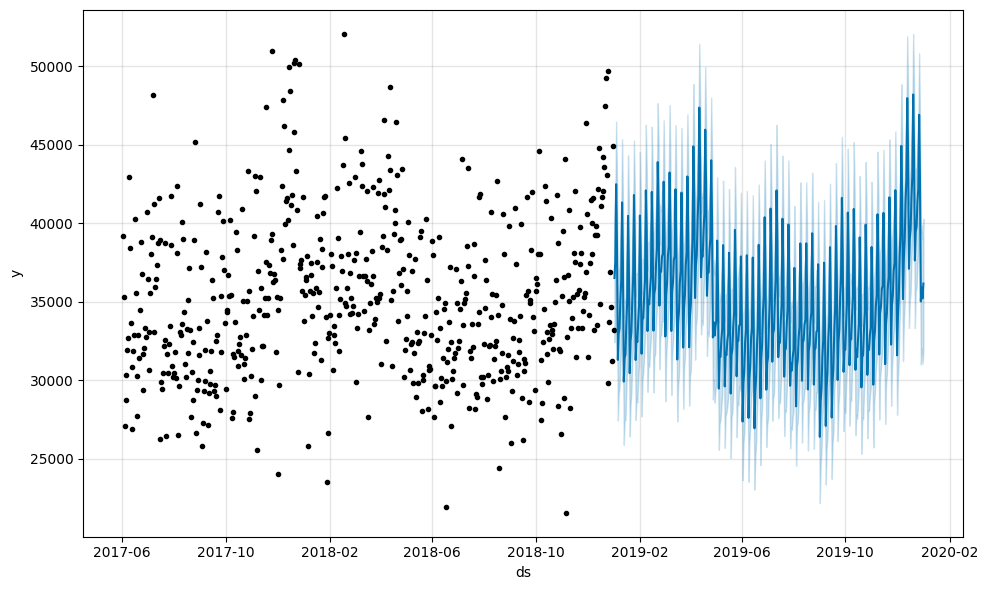

In [56]:
y_hat = m.predict(test)
_ = m.plot(y_hat)

In [57]:
pred = y_hat[y_hat['ds'].isin(test['ds'])]['yhat']
actual = test['y']
MAE = np.mean(np.abs(pred.values - actual.values))
print(f"fit MAE is: {MAE:.2f}")

fit MAE is: 2468.20


In [58]:
fact = pd.DataFrame({"pred": pred.values, "actual": actual.values})
fact.head()

,pred,actual
0,36524.405752,34536
1,37555.896791,34299
2,42500.788074,26737
3,38642.181737,31750
4,31307.327095,28513


# Add Holidays

In [62]:
import holidays

years = [2017, 2018, 2019, 2020]
vic_holidays = holidays.Australia(years=years, subdiv='VIC')
holiday_list = []
for date, name in sorted(vic_holidays.items()):
    holiday_list.append({
        'ds': date,
        'holiday': name,
        'lower_window': 0,
        'upper_window': 0
    })

holidays_df = pd.DataFrame(holiday_list)
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Impact starts 1 day before for Melbourne Cup (Monday)
holidays_df.loc[holidays_df['holiday'] == 'Melbourne Cup', 'lower_window'] = -1

# Easter Friday impact extends through the weekend
holidays_df.loc[holidays_df['holiday'] == 'Good Friday', 'upper_window'] = 3
holidays_df.head()

,ds,holiday,lower_window,upper_window
0,2017-01-01,New Year's Day,0,0
1,2017-01-02,New Year's Day (observed),0,0
2,2017-01-26,Australia Day,0,0
3,2017-03-13,Labor Day,0,0
4,2017-04-14,Good Friday,0,3


15:16:09 - cmdstanpy - INFO - Chain [1] start processing
15:16:09 - cmdstanpy - INFO - Chain [1] done processing


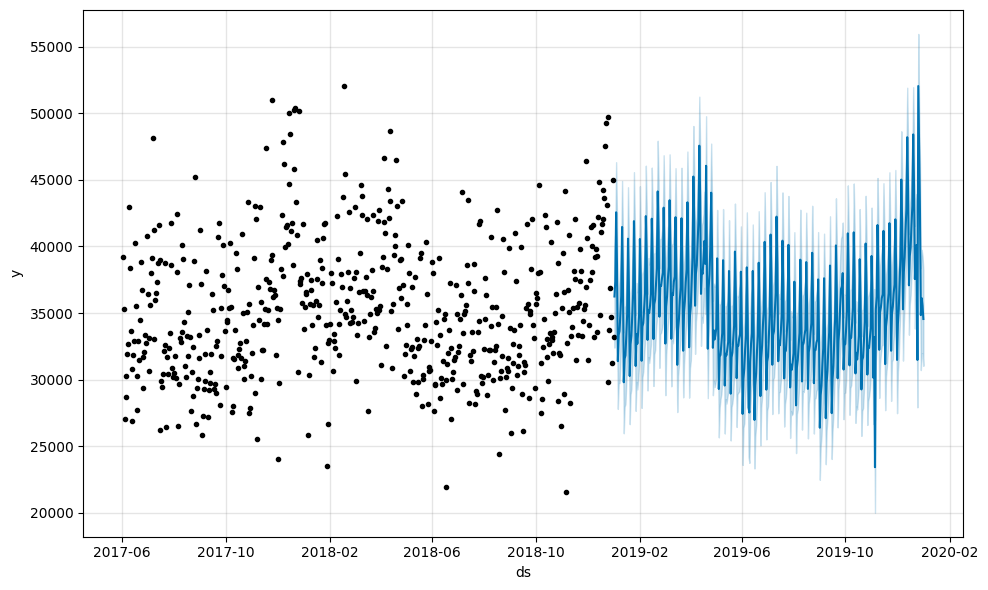

In [70]:
m = Prophet(growth="flat", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=holidays_df)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
X = df_pre[df_pre['ds'] <= "2019-01-01"]
test = df_pre[df_pre['ds'] > "2019-01-01"]
m.fit(X)

y_hat = m.predict(test)
_ = m.plot(y_hat)

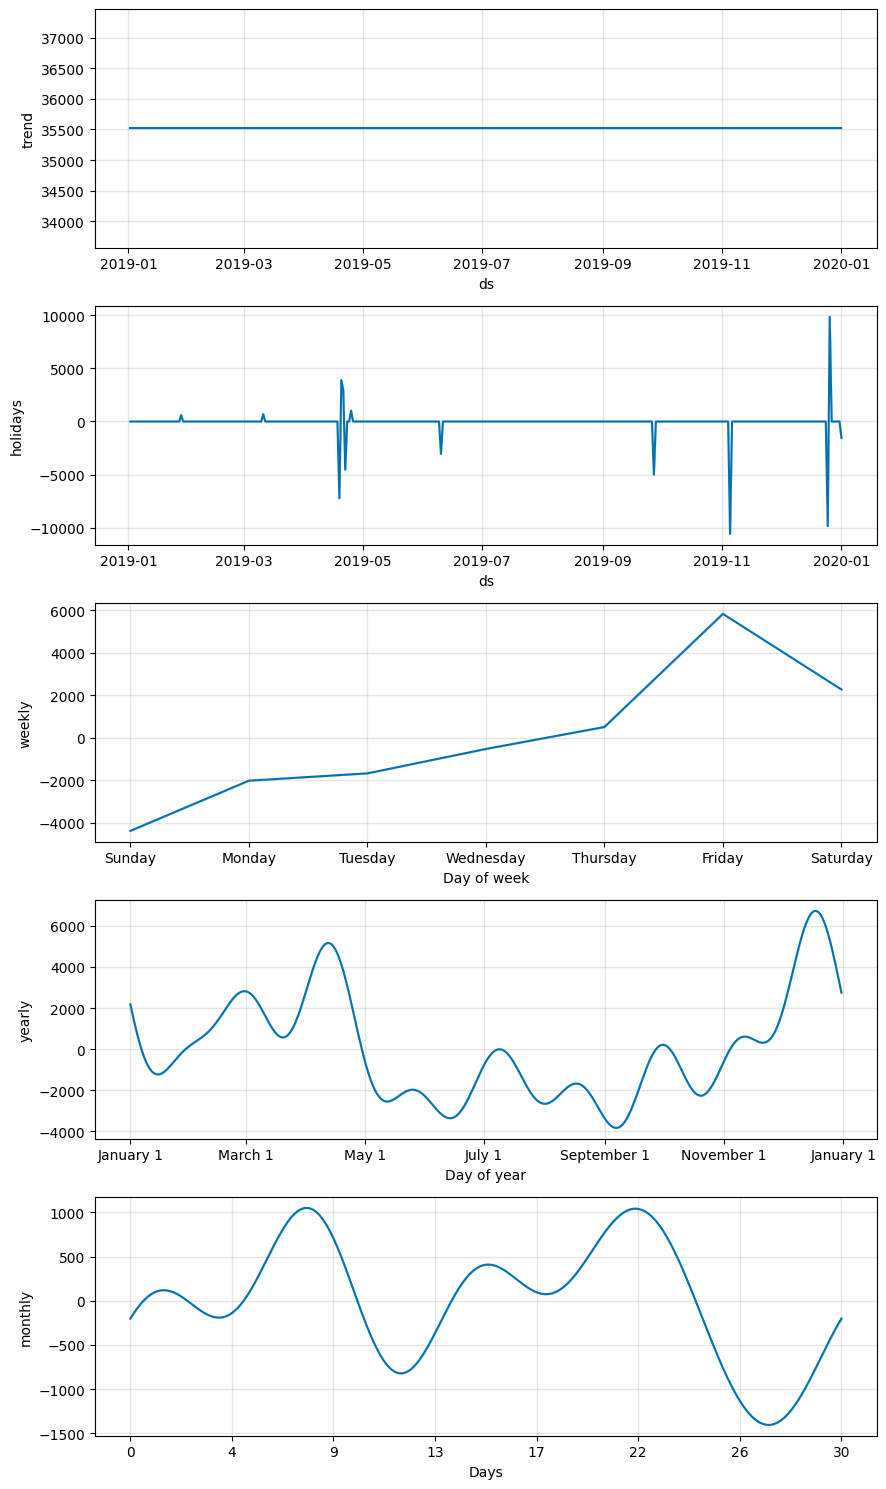

In [73]:
_ = m.plot_components(y_hat)

In [66]:
pred = y_hat[y_hat['ds'].isin(test['ds'])]['yhat']
actual = test['y']
MAE = np.mean(np.abs(pred.values - actual.values))
print(f"fit MAE is: {MAE:.2f}")

fit MAE is: 2405.33


# Full Dataset

15:17:19 - cmdstanpy - INFO - Chain [1] start processing
15:17:19 - cmdstanpy - INFO - Chain [1] done processing


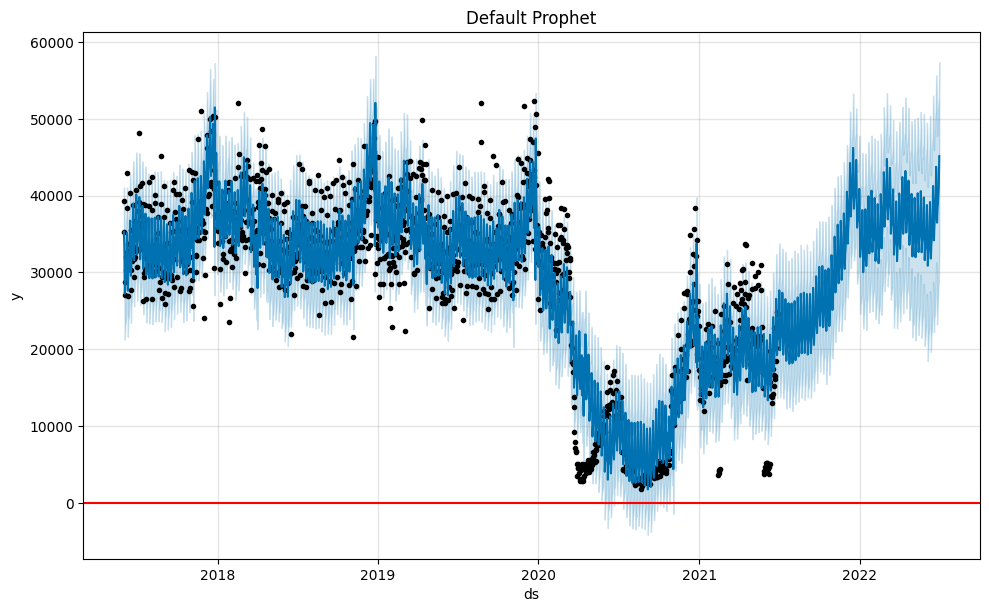

In [74]:
m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=holidays_df)
m = m.fit(df)
future = m.make_future_dataframe(periods=366)
forecast = m.predict(future)

m.plot(forecast)
plt.axhline(y=0, color='red')
plt.title('Default Prophet');


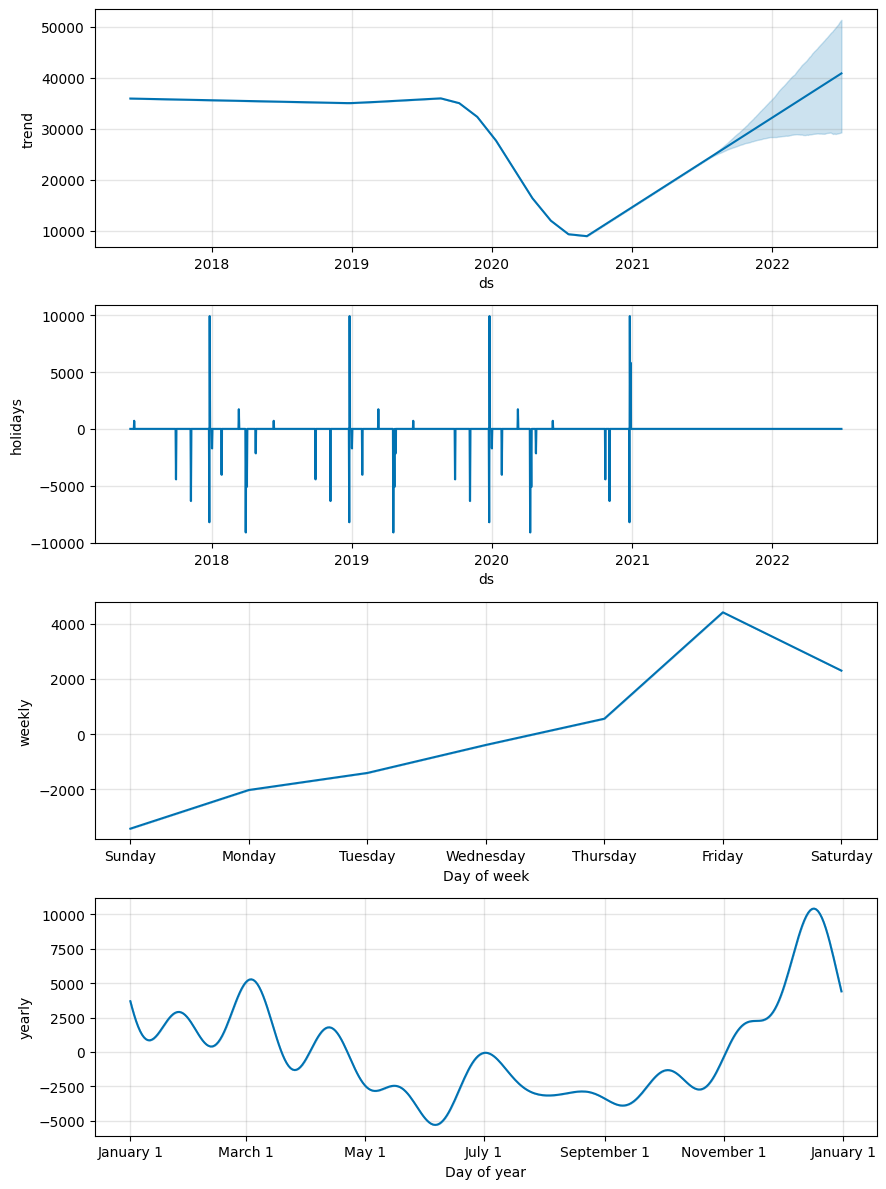

In [76]:
_ = m.plot_components(forecast)

In [78]:
print(f"detected change points are {m.changepoints.values}.")

detected change points are ['2017-07-20T00:00:00.000000000' '2017-09-05T00:00:00.000000000'
 '2017-10-23T00:00:00.000000000' '2017-12-10T00:00:00.000000000'
 '2018-01-26T00:00:00.000000000' '2018-03-15T00:00:00.000000000'
 '2018-05-01T00:00:00.000000000' '2018-06-18T00:00:00.000000000'
 '2018-08-05T00:00:00.000000000' '2018-09-21T00:00:00.000000000'
 '2018-11-08T00:00:00.000000000' '2018-12-26T00:00:00.000000000'
 '2019-02-11T00:00:00.000000000' '2019-03-31T00:00:00.000000000'
 '2019-05-18T00:00:00.000000000' '2019-07-04T00:00:00.000000000'
 '2019-08-21T00:00:00.000000000' '2019-10-08T00:00:00.000000000'
 '2019-11-24T00:00:00.000000000' '2020-01-11T00:00:00.000000000'
 '2020-02-27T00:00:00.000000000' '2020-04-15T00:00:00.000000000'
 '2020-06-02T00:00:00.000000000' '2020-07-19T00:00:00.000000000'
 '2020-09-05T00:00:00.000000000'].


# Add Covid as Holidays

In [79]:
lockdowns = pd.DataFrame([
    {'holiday': 'lockdown_1', 'ds': '2020-03-21', 'lower_window': 0, 'ds_upper': '2020-06-06'},
    {'holiday': 'lockdown_2', 'ds': '2020-07-09', 'lower_window': 0, 'ds_upper': '2020-10-27'},
    {'holiday': 'lockdown_3', 'ds': '2021-02-13', 'lower_window': 0, 'ds_upper': '2021-02-17'},
    {'holiday': 'lockdown_4', 'ds': '2021-05-28', 'lower_window': 0, 'ds_upper': '2021-06-10'},
])
for t_col in ['ds', 'ds_upper']:
    lockdowns[t_col] = pd.to_datetime(lockdowns[t_col])
lockdowns['upper_window'] = (lockdowns['ds_upper'] - lockdowns['ds']).dt.days
holidays_df_with_covid = pd.concat([holidays_df, lockdowns])
holidays_df_with_covid.tail()

,ds,holiday,lower_window,upper_window,ds_upper
53,2020-12-28,Boxing Day (observed),0,0,NaT
0,2020-03-21,lockdown_1,0,77,2020-06-06
1,2020-07-09,lockdown_2,0,110,2020-10-27
2,2021-02-13,lockdown_3,0,4,2021-02-17
3,2021-05-28,lockdown_4,0,13,2021-06-10


15:27:57 - cmdstanpy - INFO - Chain [1] start processing
15:27:58 - cmdstanpy - INFO - Chain [1] done processing


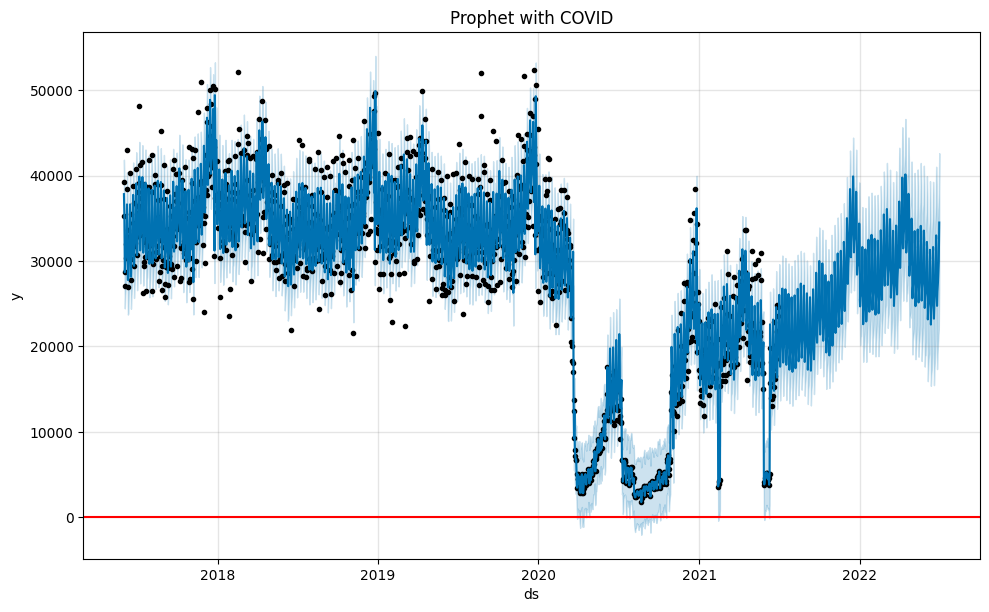

In [80]:
m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=holidays_df_with_covid)
m = m.fit(df)
future = m.make_future_dataframe(periods=366)
forecast = m.predict(future)

m.plot(forecast)
plt.axhline(y=0, color='red')
plt.title('Prophet with COVID');


# Conditional Seasonality

The weekly pedetrian behaviour could change before and after COVID.

__NOTE: CONDITION MUST BE BOOLEAN.__

In [96]:
df2 = df.copy()

df2['pre_covid'] = pd.to_datetime(df2['ds']) < pd.to_datetime('2020-03-21')
df2['post_covid'] = ~df2['pre_covid']

In [97]:
m2 = Prophet(weekly_seasonality=False, holidays=holidays_df_with_covid)
m2.add_seasonality(name="prexcovid", period=7, fourier_order=3, condition_name='pre_covid')  # indicator + fourier formulation
m2.add_seasonality(name="postxcovid", period=7, fourier_order=3, condition_name='post_covid')

m2 = m2.fit(df2)

15:46:29 - cmdstanpy - INFO - Chain [1] start processing
15:46:29 - cmdstanpy - INFO - Chain [1] done processing


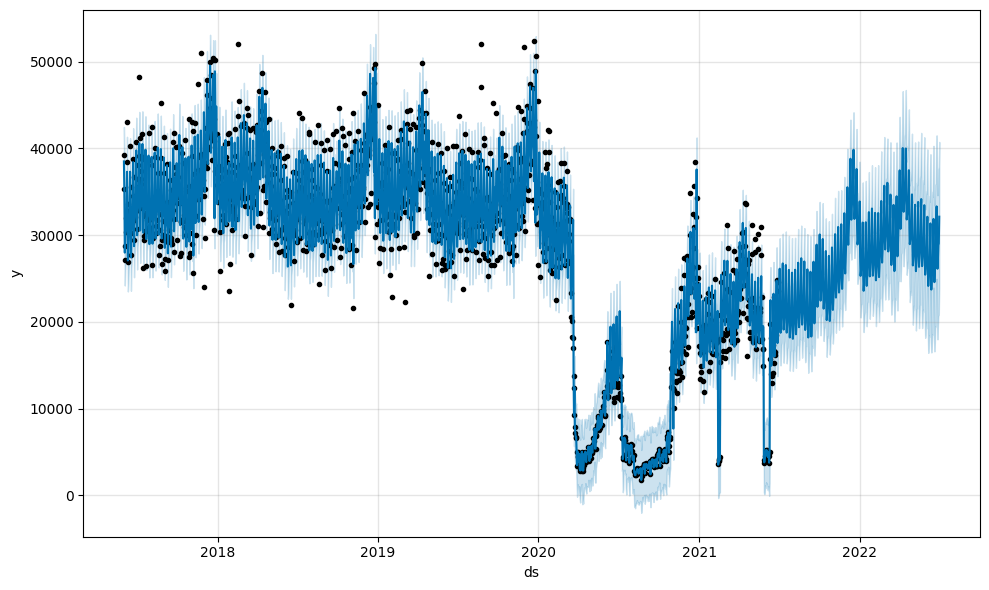

In [90]:
future2 = m2.make_future_dataframe(periods=366)
future2['pre_covid'] = pd.to_datetime(future2['ds']) < pd.to_datetime('2020-03-21')
future2['post_covid'] = ~future2['pre_covid']

forecast2 = m2.predict(future2)
_ = m2.plot(forecast2)

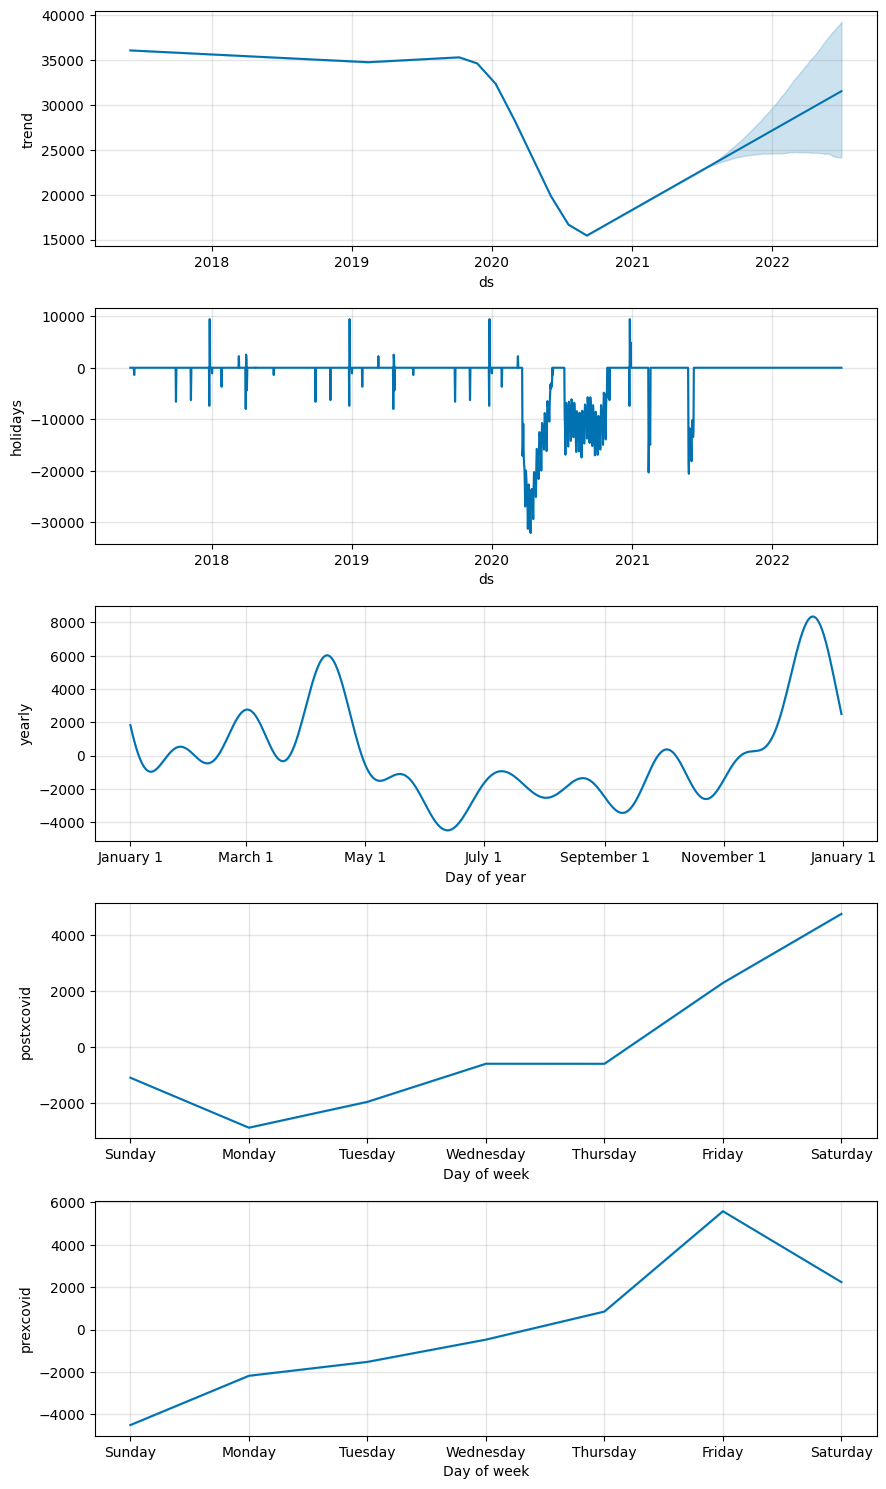

In [93]:
_ = m2.plot_components(forecast2)

# Evaluation

In [100]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

In [130]:
m = Prophet(
    weekly_seasonality=True, 
    yearly_seasonality=True, 
    daily_seasonality=False, 
    holidays=holidays_df_with_covid,
    growth="flat"
)
# df_pre is the normal period without COVID effect
m.fit(df_pre)  # df

df_cv = cross_validation(m, initial='366 days', period='180 days', horizon='60 days')
df_cv.head()

16:51:07 - cmdstanpy - INFO - Chain [1] start processing
16:51:07 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                  | 0/3 [00:00<?, ?it/s]16:51:07 - cmdstanpy - INFO - Chain [1] start processing
16:51:07 - cmdstanpy - INFO - Chain [1] done processing
 33%|██████████████                            | 1/3 [00:00<00:00,  6.19it/s]16:51:07 - cmdstanpy - INFO - Chain [1] start processing
16:51:07 - cmdstanpy - INFO - Chain [1] done processing
 67%|████████████████████████████              | 2/3 [00:00<00:00,  5.63it/s]16:51:08 - cmdstanpy - INFO - Chain [1] start processing
16:51:08 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████████████████████████████████████| 3/3 [00:00<00:00,  5.30it/s]


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2018-11-08,36818.078793,33218.292898,40611.991779,36702,2018-11-07
1,2018-11-09,42434.484774,38766.340962,46248.588812,40870,2018-11-07
2,2018-11-10,38618.988800,34843.224808,42442.087931,35058,2018-11-07
3,2018-11-11,31882.131160,28284.429349,35652.869155,28264,2018-11-07
4,2018-11-12,33979.685257,30010.326002,37887.046895,33313,2018-11-07


In [131]:
# MAE by cutoff
# The huge MAE change over 2020 indicates a changepoint there.
df_cv.groupby("cutoff").apply(lambda x: np.mean(np.abs(x['y'] - x['yhat'])))

cutoff
2018-11-07    2779.051267
2019-05-06    1640.321019
2019-11-02    3189.608793
dtype: float64

In [132]:
df_p = performance_metrics(df_cv, rolling_window=0.1)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,1.149443e+07,3390.343763,2595.503016,0.081235,0.055169,0.078828,0.666667
1,7 days,1.243029e+07,3525.662235,2755.586768,0.085038,0.055169,0.082362,0.611111
2,8 days,1.213756e+07,3483.899571,2719.405716,0.086148,0.055169,0.082703,0.611111
3,9 days,9.805953e+06,3131.445857,2255.152920,0.071031,0.041254,0.066764,0.666667
4,10 days,8.063667e+06,2839.659744,1918.176667,0.059998,0.032025,0.056558,0.777778


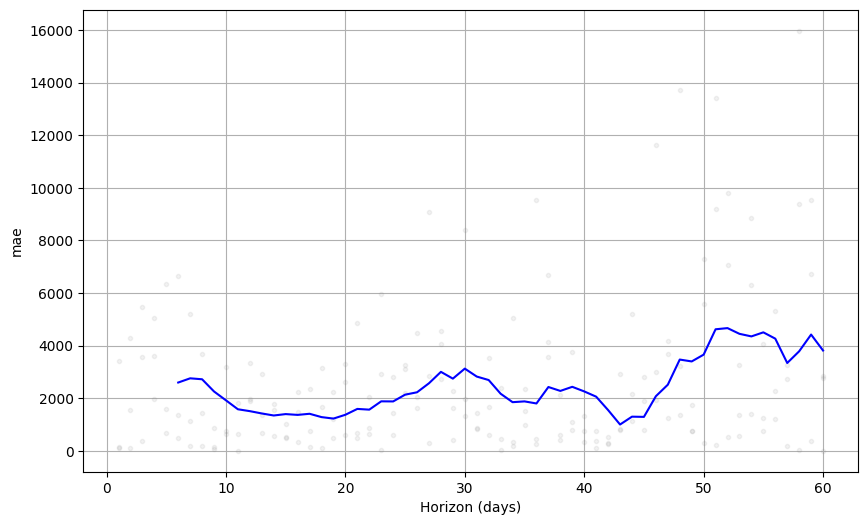

In [133]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='mae')